In [1]:
# prompt: je veux importer un zip depuis mon ordi

from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
import zipfile
with zipfile.ZipFile(fn, 'r') as zip_ref:
    zip_ref.extractall('/content')


Saving nlp_assignment.zip to nlp_assignment.zip
User uploaded file "nlp_assignment.zip" with length 70629 bytes


In [50]:
from enum import auto
# prompt: ouvre " /content/nlp_assignment/data/traindata.csv "

import pandas as pd

# Try to specify the delimiter explicitly. If the delimiter is a tab, use '\t'
df = pd.read_csv('/content/nlp_assignment/data/traindata.csv', delimiter='\t', on_bad_lines='skip',
                header=None, names=['label', 'catégorie', 'word', 'heure', 'texte'])


def insert_word_tags(row):
    word = row["word"]
    text = row["texte"]
    # encadre la première occurrence exacte du mot
    if word in text:
        return text.replace(word, f"<W>{word}</W>", 1)
    else:
        return "ERROR"  # fallback si le mot n'est pas trouvé
df["texte"] = df.apply(insert_word_tags, axis=1)


df.head()

,label,catégorie,word,heure,texte
0,positive,AMBIENCE#GENERAL,seating,18:25,short and sweet – <W>seating</W> is great:it's...
1,positive,AMBIENCE#GENERAL,trattoria,25:34,This quaint and romantic <W>trattoria</W> is a...
2,positive,FOOD#QUALITY,food,98:102,The have over 100 different beers to offer thi...
3,negative,SERVICE#GENERAL,STAFF,5:10,THIS <W>STAFF</W> SHOULD BE FIRED.
4,positive,FOOD#STYLE_OPTIONS,menu,4:8,"The <W>menu</W> looked great, and the waiter w..."


In [51]:
#! pip install transformers datasets

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import RobertaTokenizer, RobertaForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import torch
import numpy as np
import os
from collections import Counter

from transformers import RobertaConfig, RobertaForSequenceClassification
from torch.nn import CrossEntropyLoss


class RobertaForTaggedWordClassification(RobertaForSequenceClassification):
    def __init__(self, config, class_weights=None):
        super().__init__(config)
        self.roberta = self.roberta  # le backbone RoBERTa
        self.dropout = torch.nn.Dropout(config.hidden_dropout_prob)
        self.classifier = torch.nn.Linear(config.hidden_size, config.num_labels)

        if class_weights is not None:
            self.loss_fct = CrossEntropyLoss(weight=class_weights)
        else:
            self.loss_fct = CrossEntropyLoss()

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        kwargs.pop("num_items_in_batch", None)
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask, **kwargs)

        last_hidden_state = outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)

        # Trouver les positions des tokens <W> et </W>
        w_token_id = tokenizer.convert_tokens_to_ids("<W>")
        end_w_token_id = tokenizer.convert_tokens_to_ids("</W>")

        # Pour chaque exemple du batch, on extrait l'embedding entre <W> et </W>
        batch_embeddings = []

        for i in range(input_ids.size(0)):
            input_seq = input_ids[i]
            hidden_seq = last_hidden_state[i]

            try:
                start_idx = (input_seq == w_token_id).nonzero(as_tuple=True)[0].item() + 1
                end_idx = (input_seq == end_w_token_id).nonzero(as_tuple=True)[0].item()

                word_embeds = hidden_seq[start_idx:end_idx]  # (mot_length, hidden)
                pooled = word_embeds.mean(dim=0)  # moyenne sur les tokens du mot
            except Exception:
                pooled = hidden_seq[0]  # fallback si les balises ne sont pas trouvées

            batch_embeddings.append(pooled)

        pooled_output = torch.stack(batch_embeddings)  # (batch_size, hidden_size)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        if labels is not None:
            loss = self.loss_fct(logits, labels)
            return loss, logits
        return logits







#pip install transformers datasets
# Définir le token HF
HF_TOKEN = "XXX"
os.environ["WANDB_MODE"] = "disabled"

# Fusion des colonnes pour l'entrée texte
df['input'] = df['catégorie'].astype(str) + ' : ' + df['texte'].astype(str)

# Suppression des lignes incomplètes
df = df.dropna(subset=['input', 'label'])

# Encodage des labels
labels = df['label'].unique()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df['label'] = df['label'].map(label2id)

# Séparer les données en train/test sans sklearn
train_df = df[:int(0.8 * len(df))]
test_df = df[int(0.8 * len(df)):]


# Calcul des poids inverses de fréquence
label_counts = Counter(train_df['label'])
total_count = sum(label_counts.values())
class_weights = [total_count / label_counts[i] for i in range(len(labels))]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)



In [53]:
from transformers import RobertaTokenizerFast


# Convertir en Dataset
train_ds = Dataset.from_pandas(train_df[['input', 'label', 'word']])
test_ds = Dataset.from_pandas(test_df[['input', 'label', 'word']])

# 2. Tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-large", token=HF_TOKEN)
tokenizer.add_tokens(["<W>", "</W>"])

def tokenize(example):
    tokens = tokenizer(
        example["input"],
        truncation=True,
        padding="max_length",
        return_attention_mask=True  # S'assure que l'attention mask est présent
    )
    tokens["label"] = example["label"]
    return tokens


train_ds = train_ds.map(tokenize, batched=False)
test_ds = test_ds.map(tokenize, batched=False)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

Map:   0%|          | 0/1202 [00:00<?, ? examples/s]

Map:   0%|          | 0/301 [00:00<?, ? examples/s]

In [54]:

# Suppression de la colonne brute "input"
train_ds = train_ds.remove_columns(["input"])
test_ds = test_ds.remove_columns(["input"])

# Renommer la colonne pour qu'elle corresponde aux attentes du Trainer et du data collator
train_ds = train_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

# Convertir au format torch en spécifiant explicitement les colonnes
train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)



config = RobertaConfig.from_pretrained("roberta-large", num_labels=len(labels))
model = RobertaForTaggedWordClassification.from_pretrained(
    "roberta-large",
    config=config,
    token=HF_TOKEN,
    class_weights=class_weights_tensor
)


model.resize_token_embeddings(len(tokenizer))


# 4. Metrics (Calcul manuel)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Calcul de l'accuracy
    accuracy = np.sum(predictions == labels) / len(labels)

    # Calcul du F1 score
    unique_labels = np.unique(labels)
    f1 = 0
    for label in unique_labels:
        tp = np.sum((predictions == label) & (labels == label))
        fp = np.sum((predictions == label) & (labels != label))
        fn = np.sum((predictions != label) & (labels == label))
        if tp + fp + fn > 0:
            precision = tp / (tp + fp) if tp + fp > 0 else 0
            recall = tp / (tp + fn) if tp + fn > 0 else 0
            f1 += 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0
    f1 /= len(unique_labels)

    return {
        "accuracy": accuracy,
        "f1": f1,
    }
# 5. Training
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=10,
    save_strategy="no",
    report_to=None,  # Désactiver WandB
    remove_unused_columns=False  # Désactiver la suppression des colonnes non utilisées
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    data_collator=data_collator,  # remplace l'ancien tokenizer
)

trainer.train()


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaForTaggedWordClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'loss_fct.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
A ConfigError was raised whilst setting the number of model parameters in Weights & Biases config.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.585400,2.072459,0.893688,0.597468
2,2.113800,1.299756,0.877076,0.586132
3,0.103100,1.399397,0.916944,0.748525
4,1.148200,1.272665,0.916944,0.764716
5,0.005600,1.531783,0.930233,0.758203
6,0.115500,1.267098,0.930233,0.804697
7,0.163500,1.452411,0.933555,0.807298
8,0.028000,1.862825,0.933555,0.785331
9,0.106000,1.670901,0.930233,0.776036
10,0.012200,1.688759,0.933555,0.800184


TrainOutput(global_step=1510, training_loss=0.44078340267366267, metrics={'train_runtime': 3777.4001, 'train_samples_per_second': 3.182, 'train_steps_per_second': 0.4, 'total_flos': 1.116309589395456e+16, 'train_loss': 0.44078340267366267, 'epoch': 10.0})

In [55]:
datatest = pd.read_csv('/content/nlp_assignment/data/devdata.csv', delimiter='\t', on_bad_lines='skip',
                header=None, names=['label', 'catégorie', 'word', 'heure', 'texte'])

def insert_word_tags(row):
    word = row["word"]
    text = row["texte"]
    # encadre la première occurrence exacte du mot
    if word in text:
        return text.replace(word, f"<W>{word}</W>", 1)
    else:
        return "ERROR"  # fallback si le mot n'est pas trouvé
datatest["texte"] = datatest.apply(insert_word_tags, axis=1)
datatest["label"].value_counts()


,count
label,
positive,264
negative,98
neutral,14


In [56]:
import numpy as np


# Fusion des colonnes pour l'entrée texte
datatest['input'] = datatest['catégorie'].astype(str) + ' : ' + datatest['texte'].astype(str)
# Suppression des lignes incomplètes
datatest = datatest.dropna(subset=['input', 'label'])

# Encodage des labels
labels = datatest['label'].unique()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
datatest['label'] = datatest['label'].map(label2id)

# Créer un dataset de prédiction à partir de datatest en utilisant la colonne "input"
pred_ds = Dataset.from_pandas(datatest[['input']])


# Fonction de tokenisation simple sans accès aux labels
def tokenize(example):
    return tokenizer(
        example["input"],
        padding="max_length",
        truncation=True,
        return_attention_mask=True
    )

# Tokenisation
pred_ds = pred_ds.map(tokenize, batched=False)


# Remove this line: pred_ds = pred_ds.map(tokenizer, batched=True)
pred_ds = pred_ds.map(tokenize, batched=True)

# Garder uniquement les colonnes nécessaires pour le modèle
pred_ds = pred_ds.remove_columns([col for col in pred_ds.column_names if col not in ['input_ids', 'attention_mask']])
pred_ds.set_format("torch")

# Faire les prédictions avec le modèle entraîné
predictions = trainer.predict(pred_ds)

# Extraire le label prédit pour chaque exemple
pred_labels = np.argmax(predictions.predictions, axis=-1)

# Ajouter les labels prédits au DataFrame original
datatest['predicted_label'] = pred_labels


Map:   0%|          | 0/376 [00:00<?, ? examples/s]

Map:   0%|          | 0/376 [00:00<?, ? examples/s]

In [57]:
# prompt: calcule les statistiques de f1 score , accuracy et recall sur datatest

from sklearn.metrics import accuracy_score, f1_score, recall_score

# Assuming 'datatest' DataFrame has 'label' (true labels) and 'predicted_label' columns
true_labels = datatest['label'].values
predicted_labels = datatest['predicted_label'].values

accuracy = accuracy_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels, average='weighted') # Use 'weighted' for multi-class
recall = recall_score(true_labels, predicted_labels, average='weighted') # Use 'weighted' for multi-class

print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")


Accuracy: 0.898936170212766
F1 Score: 0.9008711902569077
Recall: 0.898936170212766


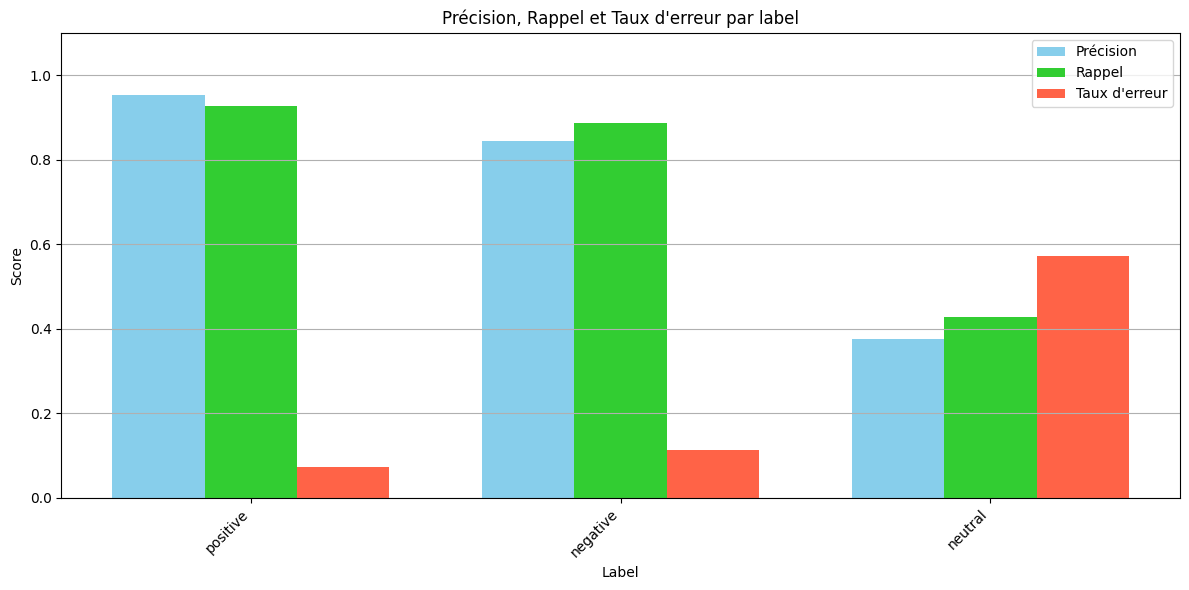

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# S'assurer que 'label' et 'predicted_label' sont bien des entiers
y_true = datatest['label'].values
y_pred = datatest['predicted_label'].values
labels = sorted(datatest['label'].unique())

# Calcul précision et rappel par classe
precision = precision_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=labels, average=None, zero_division=0)

# Taux d'erreur = 1 - accuracy locale par classe
taux_erreur = []
for label in labels:
    subset = datatest[datatest['label'] == label]
    erreurs = (subset['label'] != subset['predicted_label']).mean()
    taux_erreur.append(erreurs)

# Affichage en barres groupées
import numpy as np

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width, label='Précision', color='skyblue')
plt.bar(x, recall, width, label='Rappel', color='limegreen')
plt.bar(x + width, taux_erreur, width, label='Taux d\'erreur', color='tomato')

# Ticks et légende
plt.xticks(x, [id2label[l] for l in labels], rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Score')
plt.title('Précision, Rappel et Taux d\'erreur par label')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [59]:
datatest[datatest["label"]!=datatest["predicted_label"]]

,label,catégorie,word,heure,texte,input,predicted_label
3,1,SERVICE#GENERAL,manager,19:26,"I showed it to the <W>manager</W>, and he smil...",SERVICE#GENERAL : I showed it to the <W>manage...,0
4,2,DRINKS#QUALITY,margaritas,63:73,"The food we ordered was excellent, although I ...",DRINKS#QUALITY : The food we ordered was excel...,1
20,0,SERVICE#GENERAL,Service,0:7,<W>Service</W> was very prompt but slightly ru...,SERVICE#GENERAL : <W>Service</W> was very prom...,1
27,0,FOOD#QUALITY,food,4:8,The <W>food</W> was pretty tradional but it wa...,FOOD#QUALITY : The <W>food</W> was pretty trad...,2
35,0,FOOD#QUALITY,pasta,4:9,"The <W>pasta</W> was well cooked, didn't have ...",FOOD#QUALITY : The <W>pasta</W> was well cooke...,1
43,0,FOOD#STYLE_OPTIONS,special roll,4:16,One <W>special roll</W> and one regular roll i...,FOOD#STYLE_OPTIONS : One <W>special roll</W> a...,2
52,1,FOOD#PRICES,lobster sandwich,4:20,The <W>lobster sandwich</W> is $24 and althoug...,FOOD#PRICES : The <W>lobster sandwich</W> is $...,0
58,1,FOOD#QUALITY,food,104:108,This place is really trendi but they have forg...,FOOD#QUALITY : This place is really trendi but...,0
63,0,FOOD#QUALITY,dim sum,16:23,"The rest of the <W>dim sum</W>, though pricey ...","FOOD#QUALITY : The rest of the <W>dim sum</W>,...",1
69,2,AMBIENCE#GENERAL,atmosphere,33:43,The service was friendly and the <W>atmosphere...,AMBIENCE#GENERAL : The service was friendly an...,0


In [ ]:
real = pd.read_csv('/content/nlp_assignment/data/devdata.csv', delimiter='\t', on_bad_lines='skip',
                header=None, names=['label', 'catégorie', 'heure', 'origin', 'texte'])

In [ ]:
real['label'].value_counts()

,count
label,
positive,264
negative,98
neutral,14
